# Diffusion in Maths and AI

Many processes in nature involve random motion
 - Heat transport in solids
 - Virus particles spreading in air
 - Animals moving in ecosystems

More recently, diffusion has also become a key part of AI image generation

## Summary

Today we will explore
1. Randomly moving particles
2. How to simulate many particles
3. The link between AI models and diffusion

Run the code cell below to set everything up

In [36]:
%matplotlib inline

import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)

from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, interactive_output, VBox, HBox, Label

from IPython.display import Video, HTML

## Single diffusing particle

In [37]:
def simulate_particle(move_function, n_steps=1000, start=np.array([0.0, 0.0]), seed=0):
    npr.seed(seed)
    all_positions = np.empty((n_steps+1,2), dtype=float)
    all_positions[0,:] = start
    for t in range(n_steps):
        all_positions[t+1] = move_function(all_positions[t])
    return all_positions

def visualize_particle(all_positions, R=100):
    r = np.sqrt(all_positions[:,0]**2 + all_positions[:,1]**2)
        
    
    fig, ax = plt.subplots(1, 2)

    # Path
    ax[0].plot(all_positions[:,0], all_positions[:,1], linewidth=1.5)
    ax[0].scatter(all_positions[0,0], all_positions[0,1], s=50, marker="x")
    ax[0].scatter(all_positions[-1,0], all_positions[-1,1], s=50, marker="x", c="r")

    ax[0].set_title("Particle path")
    ax[0].set_aspect("equal")#, adjustable="box")
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y")

    # Distance
    ax[1].plot(r, linewidth=1.5)
    ax[1].set_title("Distance from start")
    ax[1].set_xlabel("step")
    ax[1].set_ylabel("r")

    plt.show()


def simulate_and_plot(n_steps=1000, seed=0):
    visualize_particle(simulate_particle(move_particle, n_steps=n_steps, seed=seed))

def make_interactive_plot():
    steps=IntSlider(value=500, min=50, max=2000, step=50)
    seed=IntSlider(value=0, min=0, max=20, step=1)
    
    out = interactive_output(simulate_and_plot, {"n_steps": steps, "seed":seed})
    
    return VBox([HBox([Label("Steps:"), steps]), HBox([Label("Seed:"), seed]), out])


In [38]:
def move_particle(position, epsilon=0.1):
    delta = epsilon*npr.randn(2)
    return position + delta

In [39]:
make_interactive_plot()



### What happens if we change move_particle?

## Many diffusing particles

In [85]:
def simulate_many_particles(move_function, n_steps=1000, n_particles=200, start=np.array([0.0, 0.0]), seed=0):
    npr.seed(seed)
    all_positions = np.empty((n_steps+1,n_particles,2), dtype=float)
    all_positions[0,:,:] = start
    for t in range(n_steps):
        all_positions[t+1] = move_function(all_positions[t])
    return all_positions

def visualize_many_particles(all_positions, step=0, R=100):
    positions = all_positions[step]

    x = positions[:,0]
    y = positions[:,1]

    
    r = np.sqrt(positions[:,0]**2 + positions[:,1]**2)
        
    
    fig, ax = plt.subplots(1, 2)


    N = min(100, len(x))
    # Particles
    ax[0].set_title("Particles")
    ax[0].scatter(x[:N], y[:N])

    hist, yedges, xedges = np.histogram2d(x, y, bins=20, density=True)

    ax[1].pcolormesh(xedges, yedges, hist)
    ax[1].set_title("Particle density (all)")
    ax[1].set_aspect("equal")#, adjustable="box")
    ax[1].set_xlabel("x")
    ax[1].set_ylabel("y")
    plt.show()


def simulate_and_plot(n_steps=1000, seed=0):
    visualize_many_particles(simulate_many_particles(move_many_particles, n_steps=n_steps, seed=seed), step=n_steps)


In [86]:
def make_interactive_plot():
    steps=IntSlider(value=500, min=0, max=2000, step=50)
    seed=IntSlider(value=0, min=0, max=20, step=1)
    
    out = interactive_output(simulate_and_plot, {"n_steps": steps, "seed":seed})
    
    return VBox([HBox([Label("Steps:"), steps]), HBox([Label("Seed:"), seed]), out])

In [87]:
def move_many_particles(positions, epsilon=1.0):
    delta = epsilon*npr.randn(*positions.shape)
    return positions + delta

In [88]:
make_interactive_plot()

### Average displacement vs time

In [89]:
def show_average_displacement(
    n_particles=200,
    n_steps=500,
    epsilon=1.0,
    seed=0,
):
    all_positions = simulate_many_particles(move_many_particles, n_steps=n_steps, seed=seed)
    mean_displacement = np.mean(np.sqrt(all_positions[:,:,0]**2 + all_positions[:,:,1]**2), axis=1)
    plt.figure()
    plt.plot(np.arange(n_steps+1), mean_displacement)
    plt.show()
    

In [90]:
def make_interactive_plot():
    steps=IntSlider(value=500, min=0, max=2000, step=50)
    seed=IntSlider(value=0, min=0, max=20, step=1)
    
    out = interactive_output(show_average_displacement, {"n_steps": steps, "seed":seed})
    
    return VBox([HBox([Label("Steps:"), steps]), HBox([Label("Seed:"), seed]), out])

In [91]:
make_interactive_plot()

## Diffusion and AI image generation

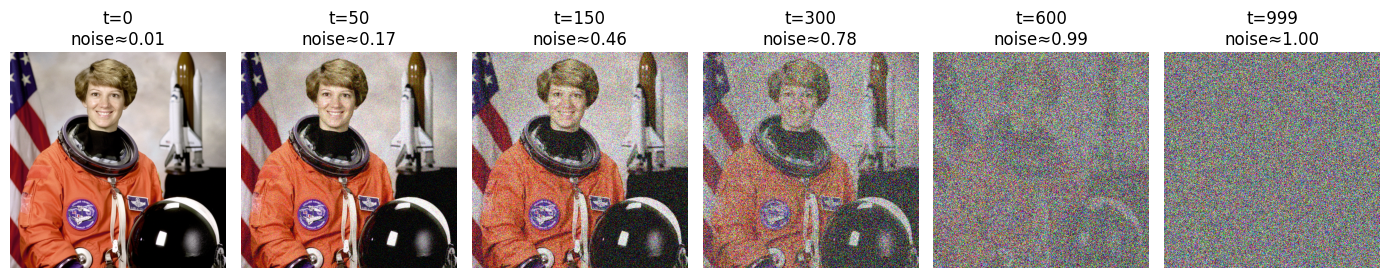

In [96]:
from skimage import data, img_as_float

def ddpm_linear_beta_schedule(T, beta_start=1e-4, beta_end=2e-2):
    return np.linspace(beta_start, beta_end, T, dtype=np.float64)

def q_sample(x0, t, sqrt_alpha_bar, sqrt_one_minus_alpha_bar, rng):
    eps = npr.randn(*x0.shape)
    return sqrt_alpha_bar[t] * x0 + sqrt_one_minus_alpha_bar[t] * eps

x0 = 2*img_as_float(data.astronaut())-1  

# DDPM schedule
T = 1000
betas = ddpm_linear_beta_schedule(T)
alphas = 1.0 - betas
alpha_bar = np.cumprod(alphas)

sqrt_alpha_bar = np.sqrt(alpha_bar)
sqrt_one_minus_alpha_bar = np.sqrt(1.0 - alpha_bar)

steps_to_show = [0, 50, 150, 300, 600, 999]
rng = np.random.default_rng(0)

plt.figure(figsize=(14, 3))
for i, t in enumerate(steps_to_show, 1):
    xt = q_sample(x0, t, sqrt_alpha_bar, sqrt_one_minus_alpha_bar, rng)
    xt = np.clip(0.5*(xt+1), 0, 1)

    plt.subplot(1, len(steps_to_show), i)
    plt.imshow(xt)
    plt.title(f"t={t}\nnoise≈{sqrt_one_minus_alpha_bar[t]:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [94]:
### Neural networks learn to remove noise from images